In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Данные

Эти данные содержат описание гипотетических примеров для 23 видов грибов из семейства шампиньоновых. Каждый вид характеризуется либо как съедобный, либо как ядовитый, либо неизвестной съедобности (не рекомендуется в пищу). Этот последний класс был объединён с классом ядовитых.


Информация об атрибутах:

1. cap-shape: bell=b,conical=c,convex=x,flat=f, knobbed=k,sunken=s
2. cap-surface: fibrous=f,grooves=g,scaly=y,smooth=s
3. cap-color: brown=n,buff=b,cinnamon=c,gray=g,green=r, pink=p,purple=u,red=e,white=w,yellow=y
4. bruises?: bruises=t,no=f
5. odor: almond=a,anise=l,creosote=c,fishy=y,foul=f, musty=m,none=n,pungent=p,spicy=s
6. gill-attachment: attached=a,descending=d,free=f,notched=n
7. gill-spacing: close=c,crowded=w,distant=d
8. gill-size: broad=b,narrow=n
9. gill-color: black=k,brown=n,buff=b,chocolate=h,gray=g, green=r,orange=o,pink=p,purple=u,red=e, white=w,yellow=y
10. stalk-shape: enlarging=e,tapering=t
11. stalk-root: bulbous=b,club=c,cup=u,equal=e, rhizomorphs=z,rooted=r,missing=?
12. stalk-surface-above-ring: fibrous=f,scaly=y,silky=k,smooth=s
13. stalk-surface-below-ring: fibrous=f,scaly=y,silky=k,smooth=s
14. stalk-color-above-ring: brown=n,buff=b,cinnamon=c,gray=g,orange=o, pink=p,red=e,white=w,yellow=y
15. stalk-color-below-ring: brown=n,buff=b,cinnamon=c,gray=g,orange=o, pink=p,red=e,white=w,yellow=y
16. veil-type: partial=p,universal=u
17. veil-color: brown=n,orange=o,white=w,yellow=y
18. ring-number: none=n,one=o,two=t
19. ring-type: cobwebby=c,evanescent=e,flaring=f,large=l, none=n,pendant=p,sheathing=s,zone=z
20. spore-print-color: black=k,brown=n,buff=b,chocolate=h,green=r, orange=o,purple=u,white=w,yellow=y
21. population: abundant=a,clustered=c,numerous=n, scattered=s,several=v,solitary=y
22. habitat: grasses=g,leaves=l,meadows=m,paths=p, urban=u,waste=w,woods=d

# Цель

**Цель будет не в том, чтобы создать модель предсказания!**

Наша общая цель в данной задаче состоит в том, чтобы с помощью машинного обучения и бустинга создать не просто предиктивную модель, а общее руководство по характеристикам, на которые нужно обращать внимание при собирании грибов.

In [7]:
df = pd.read_csv(r"mushrooms.csv")

In [8]:
df

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,e,k,s,n,f,n,a,c,b,y,...,s,o,o,p,o,o,p,b,c,l
8120,e,x,s,n,f,n,a,c,b,y,...,s,o,o,p,n,o,p,b,v,l
8121,e,f,s,n,f,n,a,c,b,n,...,s,o,o,p,o,o,p,b,c,l
8122,p,k,y,n,f,y,f,c,n,b,...,k,w,w,p,w,o,e,w,v,l


class e - edible    - сьедобный

class p - poisonous - ядовитый

<Axes: xlabel='class', ylabel='count'>

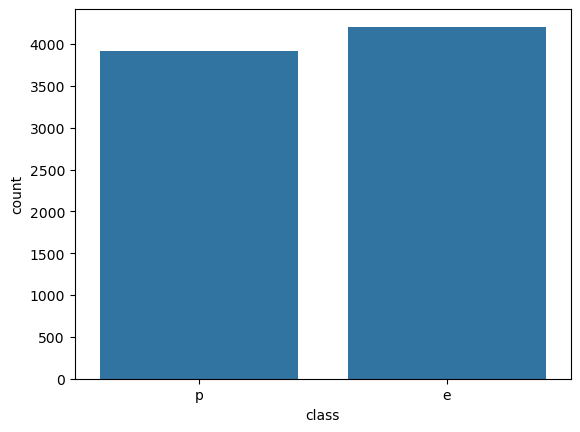

In [9]:
sns.countplot(data = df, x='class')

In [10]:
df.describe()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,...,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


count - колво признаков

unique - уникальных данных сколько

top	 - популярный класс

freq - сколько признаков top

In [11]:
feat_uni = df.describe().T.reset_index().sort_values('unique')

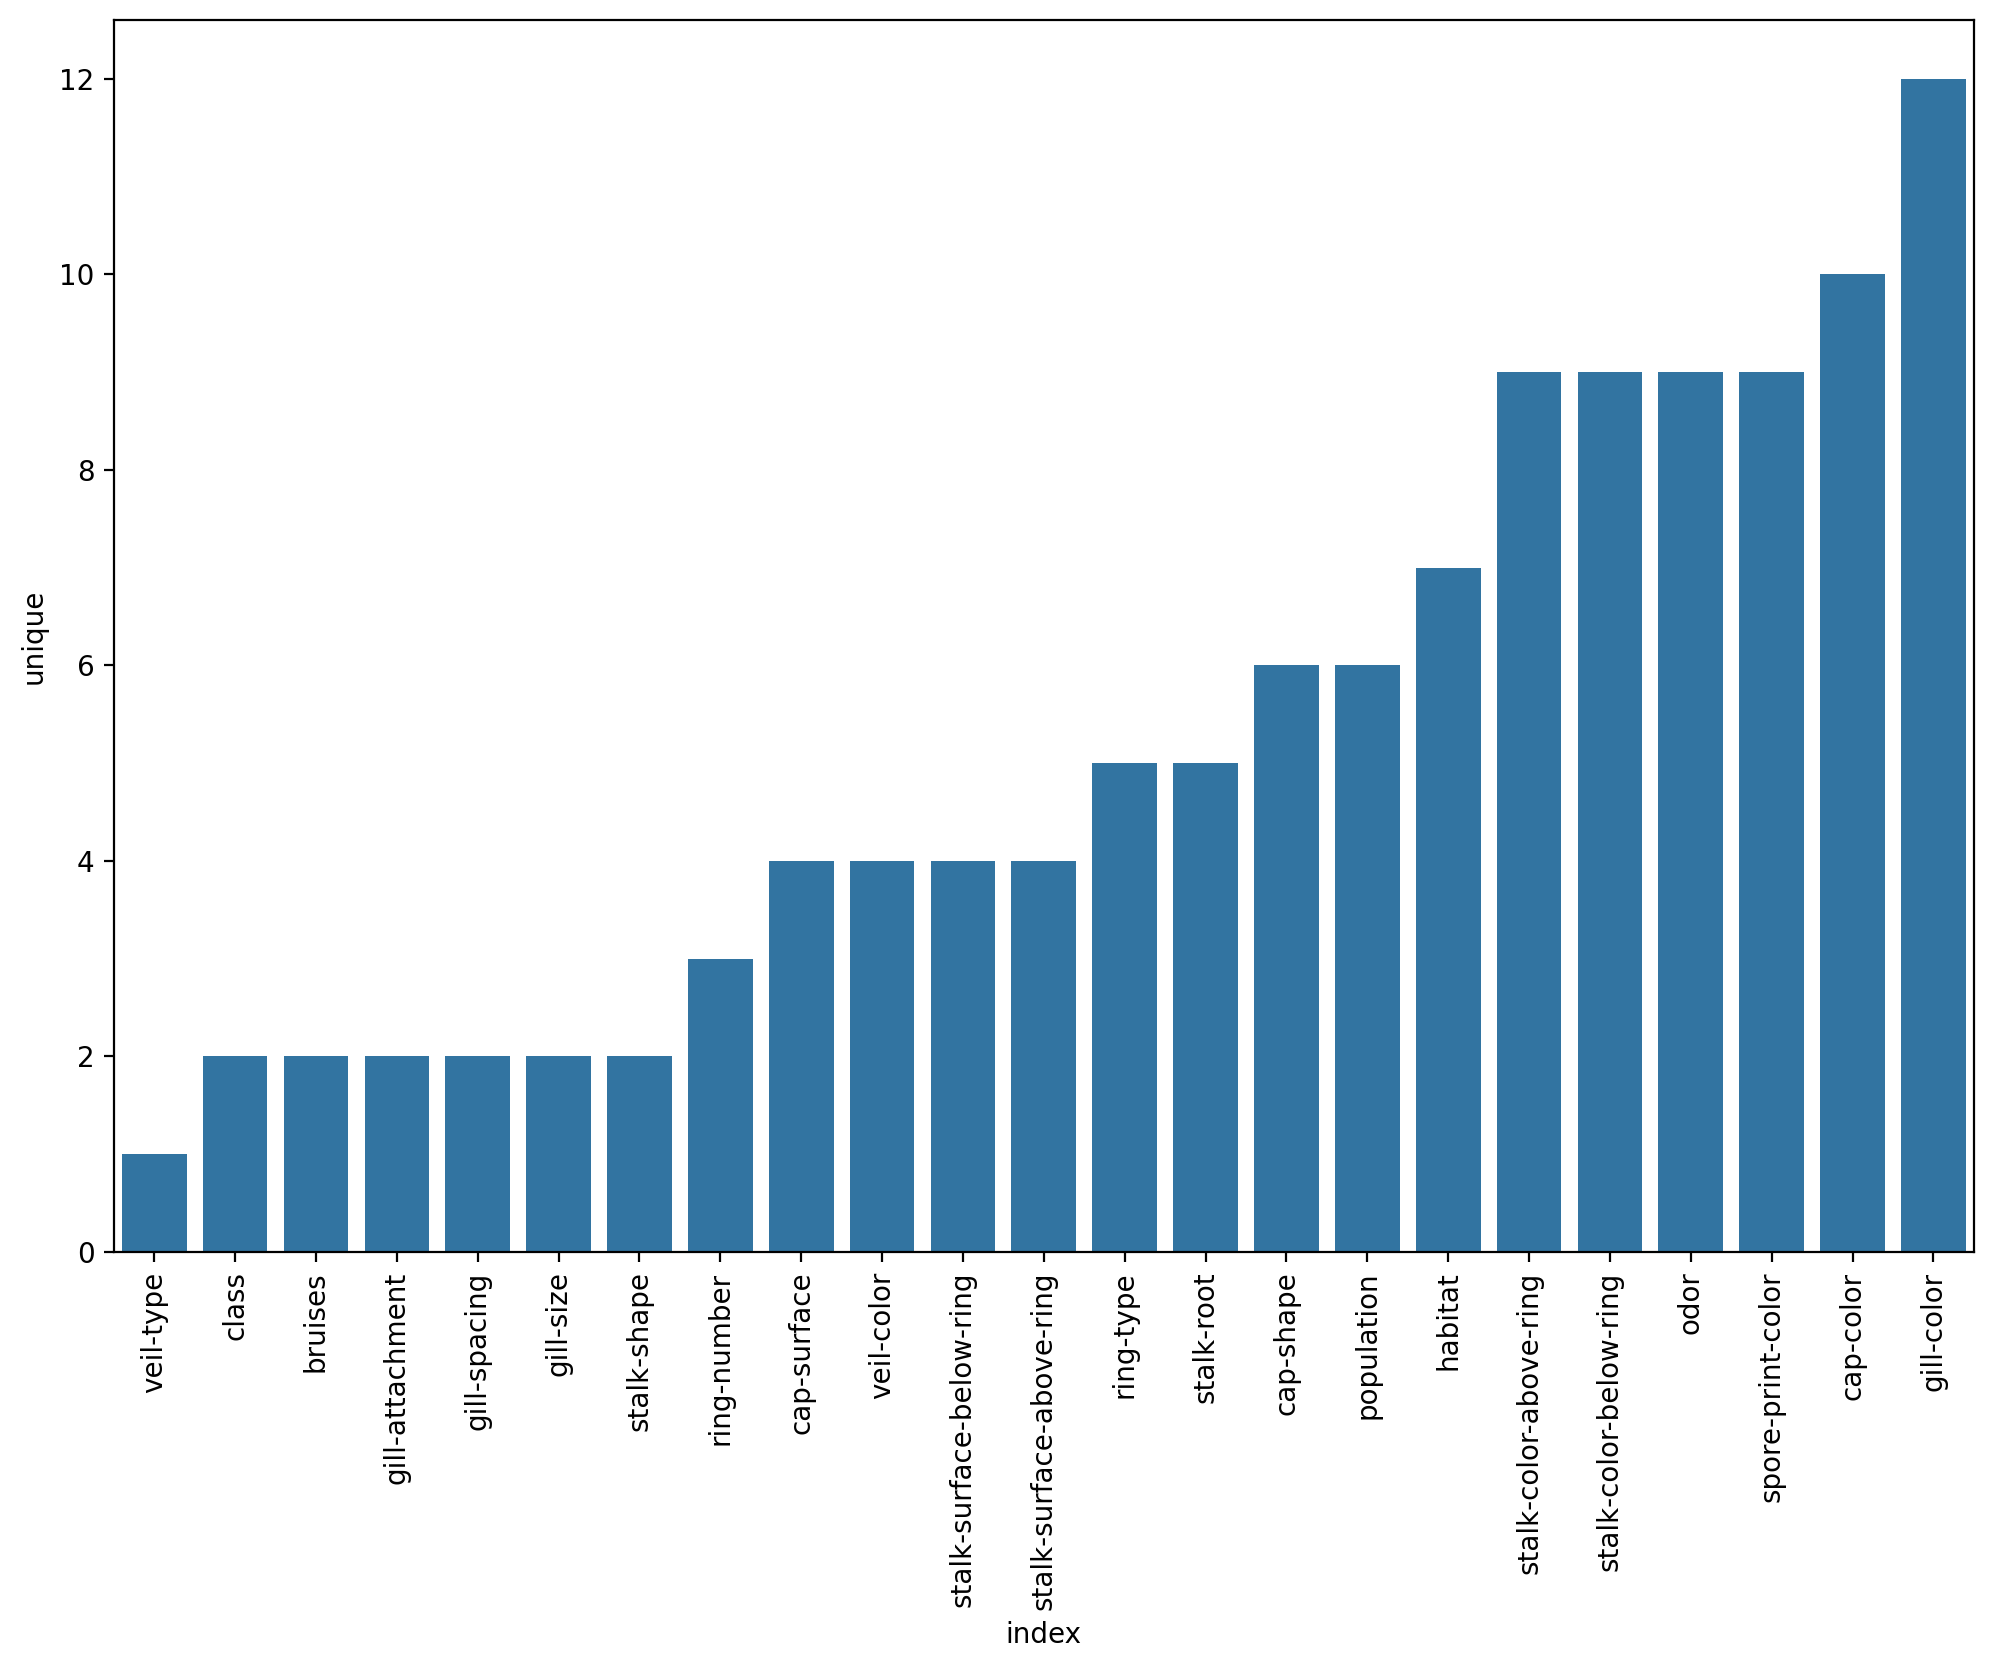

In [12]:
fig, ax = plt.subplots(figsize=(12,8), dpi=200)
sns.barplot(data=feat_uni, x='index', y='unique', ax=ax)
plt.xticks(rotation=90);

In [13]:
X = df.drop('class', axis=1)

In [14]:
X.isnull().sum()

cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64

X имеет категориальные переменные, поэтому нужно преобразровать в dummy переменные

In [15]:
X = pd.get_dummies(X, drop_first=True)
y = df['class']

In [16]:
from sklearn.model_selection import train_test_split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=101)

In [18]:
from sklearn.ensemble import AdaBoostClassifier

In [19]:
# base_estimater - базоваямодель машинного обучения
# n_estimatros  - модель должна выбирать 1 наилучший признак, по которому выбирать разбиения данных

In [20]:
model = AdaBoostClassifier(n_estimators=1) 
model.fit(X_train, y_train)

,estimator,None
,n_estimators,1
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,None


In [21]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score

In [22]:
predict = model.predict(X_test)

In [23]:
print(classification_report(y_test, predict))

              precision    recall  f1-score   support

           e       0.96      0.81      0.88       655
           p       0.81      0.96      0.88       564

    accuracy                           0.88      1219
   macro avg       0.88      0.88      0.88      1219
weighted avg       0.89      0.88      0.88      1219



In [24]:
# по какому признаку разбиение данных:
# в нашей модели состоит из 1 дерева и с одним признаком

In [25]:
model.feature_importances_

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [26]:
model.feature_importances_.argmax()

np.int64(22)

In [27]:
X.columns[22]

'odor_n'

# если хотим понять сьедобный гриб или нет, при этом выбрав один признак, то наша модель говорит, что лучше всего просто понюхать гриб, что нам говорит признак odor_n

<Axes: xlabel='odor', ylabel='count'>

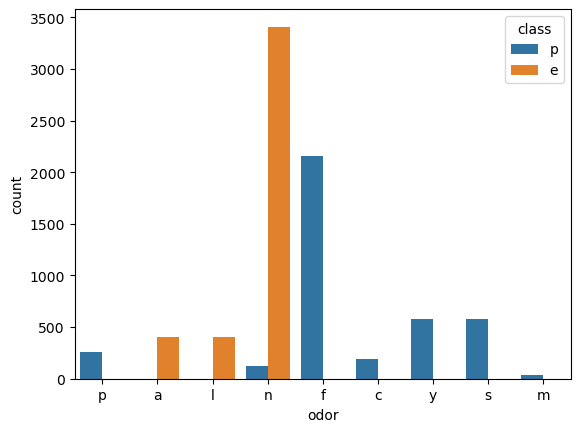

In [28]:
sns.countplot(data=df, x='odor', hue='class')
# показывает почему критерий запах сильно влияет

In [29]:
len(X.columns)

95

In [ ]:
from tqdm import tqdm

error_rates = []

for n in tqdm(range(1, 96)):
    model = AdaBoostClassifier(n_estimators=n)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    error = 1 - accuracy_score(y_test, preds)
    error_rates.append(error)

 34%|███████████████████████████▌                                                      | 32/95 [00:16<00:57,  1.09it/s]

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8), dpi=200)

ax.plot(range(1, 96), error_rates)
ax.set_xlim(1, 96)
ax.set_xticks(range(1, 96, 2))
ax.grid()

In [ ]:
model.feature_importances_.argmax()

# после этого нам модель, в которой модель с n_estimators=95 говорит, что наиболее важный признак c индексом 80

In [ ]:
feats = pd.DataFrame(index=X.columns, data=model.feature_importances_, columns=['Важность'])
imp_feat = feats[feats['Важность'] > 0]
imp_feat.sort_values('Важность', ascending=False, inplace=True)

In [ ]:

fig, ax = plt.subplots(figsize=(12, 8), dpi=200)
sns.barplot(data=imp_feat, x=imp_feat.index, y='Важность', ax=ax)
plt.xticks(ticks=imp_feat.index,rotation=90);